In [113]:
%load_ext autoreload
%autoreload 2

from data_loader import load_all_results
import pandas as pd
import plot_functions
import matplotlib.pyplot as plt
import math
import main
import pickle

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [115]:
data = load_all_results("../results")
intersected_datasets = main.intersect_on_election(*data.values())
for idx, key in enumerate(data.keys()):
    data[key] = intersected_datasets[idx]
    
# Save the data to a file named 'data.pkl'
with open('data.pkl', 'wb') as file:
    pickle.dump(data, file)

In [116]:
with open('data.pkl', 'rb') as file:
    loaded_dictionary = pickle.load(file)

In [117]:
plt.style.use('seaborn-v0_8-muted')

In [104]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


## Efficiency Comparisons

### Compare spending efficiency of MES Add-One and EES Add-opt
The purpose of this plot is to compare the new add-opt method with ees and the existing method used in practice (mes add-one). We wish to show that ours does better on a nontrivial number of instances.

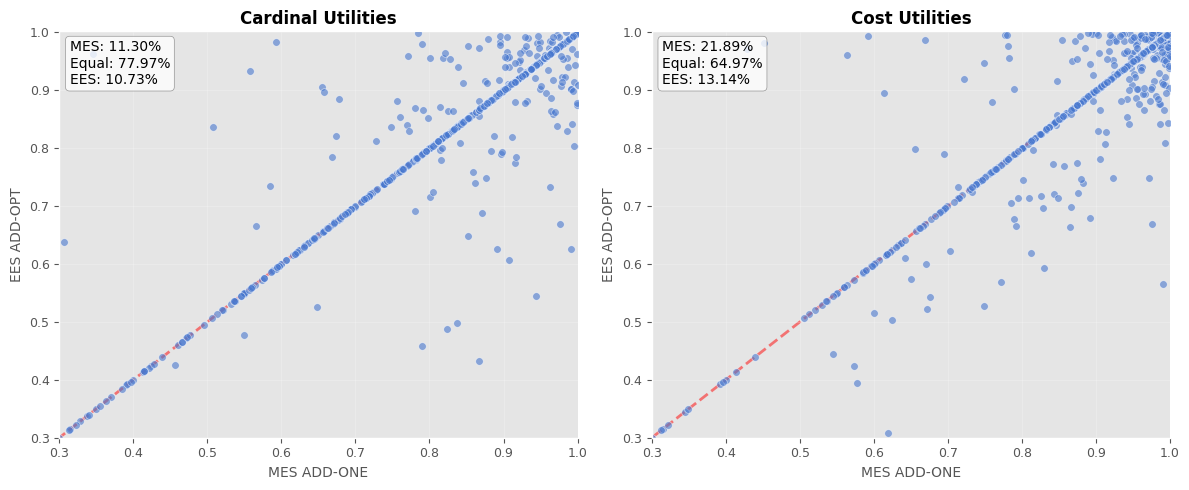

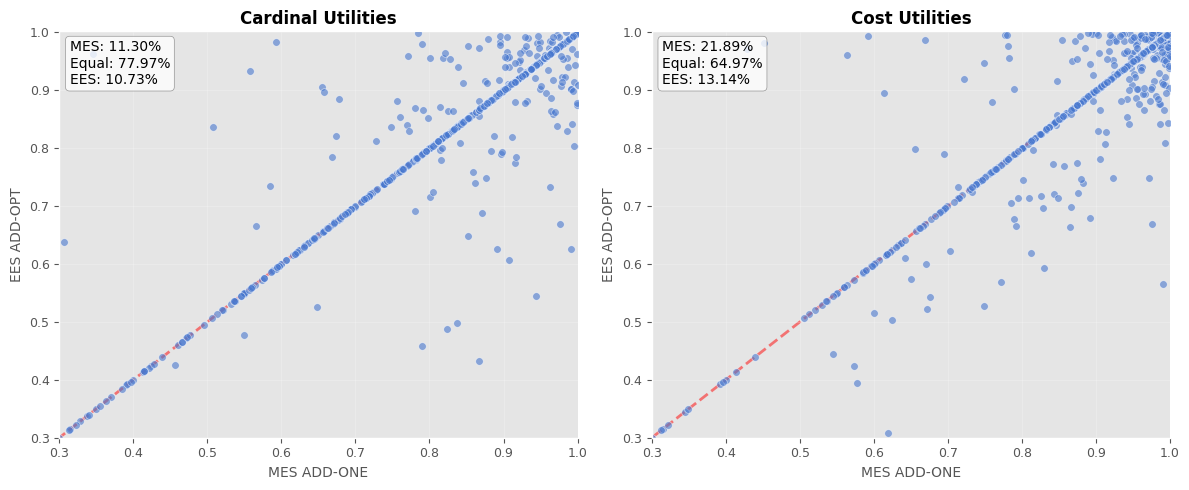

In [118]:
ees_cardinal_add_opt = data['ees_cardinal_add_opt']
mes_cardinal_add_one = data['mes_cardinal_add_one']
ees_cardinal_add_opt, mes_cardinal_add_one = main.intersect_on_election(ees_cardinal_add_opt, mes_cardinal_add_one)

ees_cost_add_opt = data['ees_cost_add_opt']
mes_cost_add_one = data['mes_cost_add_one']
ees_cost_add_opt, mes_cost_add_one = main.intersect_on_election(ees_cost_add_opt, mes_cost_add_one)

plot_functions.comparison_scatter_plot(x1=mes_cardinal_add_one['highest_efficiency_attained'],
                        y1=ees_cardinal_add_opt["highest_efficiency_attained"],
                        x2=mes_cost_add_one['highest_efficiency_attained'],
                        y2=ees_cost_add_opt['highest_efficiency_attained'],
                        x_label='MES ADD-ONE',
                        y_label='EES ADD-OPT',
                        percentage_labels={'first': 'MES', 'equal': 'Equal', 'second': 'EES'})

In [130]:
main.count_thresholds(
    ees_cardinal_add_opt["highest_efficiency_attained"],
    mes_cardinal_add_one["highest_efficiency_attained"],
    label_a="EES Add-Opt",
    label_b="MES Add-One",
    context="Cardinal"
)
print("\n")
main.count_thresholds(
    ees_cost_add_opt["highest_efficiency_attained"],
    mes_cost_add_one["highest_efficiency_attained"],
    label_a="EES Add-Opt",
    label_b="MES Add-One",
    context="Cost"
)

Cardinal EES Add-Opt vs MES Add-One (n=708):
 >1.0 times=76
 1.1 times=29
 1.25 times=10
 1.5 times=5
 2.0 times=2
 max=2.79
 median=1.07
 mean=1.15


Cost EES Add-Opt vs MES Add-One (n=708):
 >1.0 times=91
 1.1 times=25
 1.25 times=13
 1.5 times=6
 2.0 times=4
 max=11.04
 median=1.04
 mean=1.25


In [131]:
main.count_thresholds(
    mes_cardinal_add_one["highest_efficiency_attained"],
    ees_cardinal_add_opt["highest_efficiency_attained"],
    label_a="MES Add-One",
    label_b="EES Add-Opt",
    context="Cardinal"
)
print("\n")
main.count_thresholds(
    mes_cost_add_one["highest_efficiency_attained"],
    ees_cost_add_opt["highest_efficiency_attained"],
    label_a="MES Add-One",
    label_b="EES Add-Opt",
    context="Cost"
)

Cardinal MES Add-One vs EES Add-Opt (n=708):
 >1.0 times=71
 1.1 times=37
 1.25 times=12
 1.5 times=6
 2.0 times=0
 max=2.00
 median=1.11
 mean=1.17


Cost MES Add-One vs EES Add-Opt (n=708):
 >1.0 times=149
 1.1 times=55
 1.25 times=14
 1.5 times=3
 2.0 times=2
 max=3.00
 median=1.06
 mean=1.11


### Compare spending efficiency of EES Add-ONE and EES Add-OPT Exhaustive
The purposed of this plot is to show that add-opt is finding more of the best budgets than add-one. In particular, add-opt should find all (almost) of the budgets, and so should be achieving the optimal for ees.

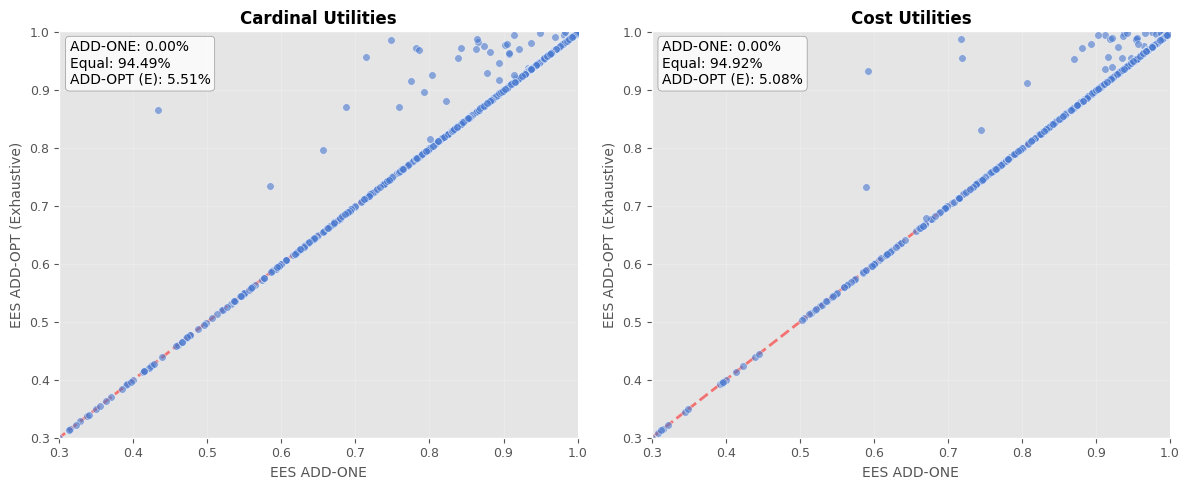

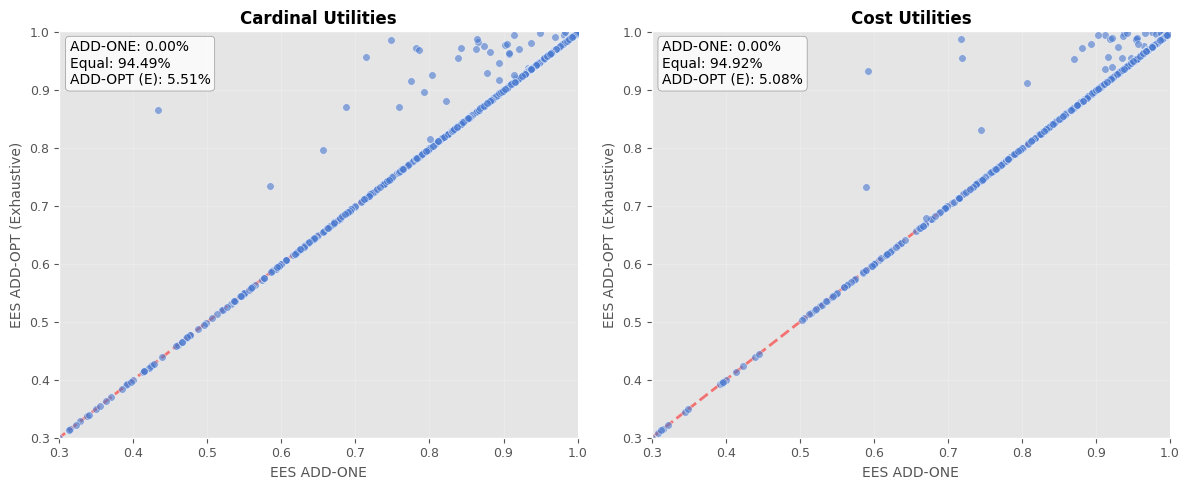

In [120]:
ees_cardinal_add_one = data['ees_cardinal_add_one']
ees_cardinal_add_opt_exhaustive = data['ees_cardinal_add_opt_exhaustive']
ees_cardinal_add_opt_exhaustive, ees_cardinal_add_one = main.intersect_on_election(ees_cardinal_add_opt_exhaustive, ees_cardinal_add_one)

ees_cost_add_one = data['ees_cost_add_one']
ees_cost_add_opt_exhaustive = data['ees_cost_add_opt_exhaustive']
ees_cost_add_opt_exhaustive, ees_cost_add_one = main.intersect_on_election(ees_cost_add_opt_exhaustive, ees_cost_add_one)

plot_functions.comparison_scatter_plot(x1=ees_cardinal_add_one['highest_efficiency_attained'],
                        y1=ees_cardinal_add_opt_exhaustive["highest_efficiency_attained"],
                        x2=ees_cost_add_one['highest_efficiency_attained'],
                        y2=ees_cost_add_opt_exhaustive['highest_efficiency_attained'],
                        x_label='EES ADD-ONE',
                        y_label='EES ADD-OPT (Exhaustive)',
                        percentage_labels={'first': 'ADD-ONE', 'equal': 'Equal', 'second': 'ADD-OPT (E)'})

In [121]:
main.count_thresholds(
    ees_cardinal_add_opt_exhaustive["highest_efficiency_attained"],
    ees_cardinal_add_one["highest_efficiency_attained"],
    label_a="EES Add-Opt (Exhaustive)",
    label_b="EES Add-One",
    context="Cardinal"
)

main.count_thresholds(
    ees_cost_add_opt_exhaustive["highest_efficiency_attained"],
    ees_cost_add_one["highest_efficiency_attained"],
    label_a="EES Add-Opt (Exhaustive)",
    label_b="EES Add-One",
    context="Cost"
)

Cardinal EES Add-Opt (Exhaustive) vs EES Add-One (n=708):
 >1.0 times=39
 1.1 times=19
 1.25 times=6
 1.5 times=2
 2.0 times=2
 max=11.04
 median=1.10
 mean=1.39
Cost EES Add-Opt (Exhaustive) vs EES Add-One (n=708):
 >1.0 times=36
 1.1 times=9
 1.25 times=4
 1.5 times=2
 2.0 times=1
 max=11.04
 median=1.05
 mean=1.36


### Compare spending efficiency of MES Add-ONE and EES Add-OPT-SKIP
The purpose of this plot is to see how the skip heuristic compares to the current method used in practice. In particular this is interesting since the skip method runs in time similar to MES Add-One.

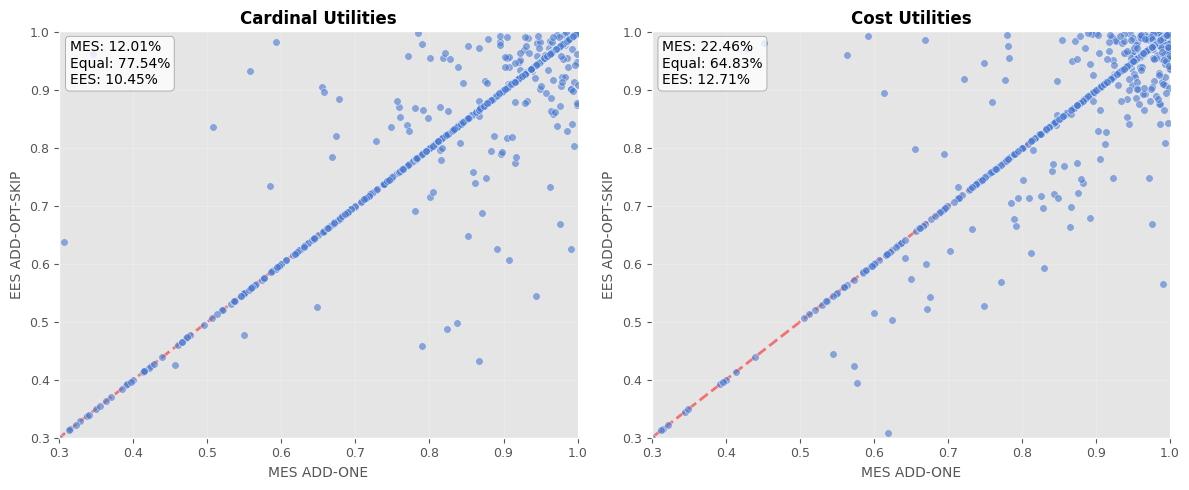

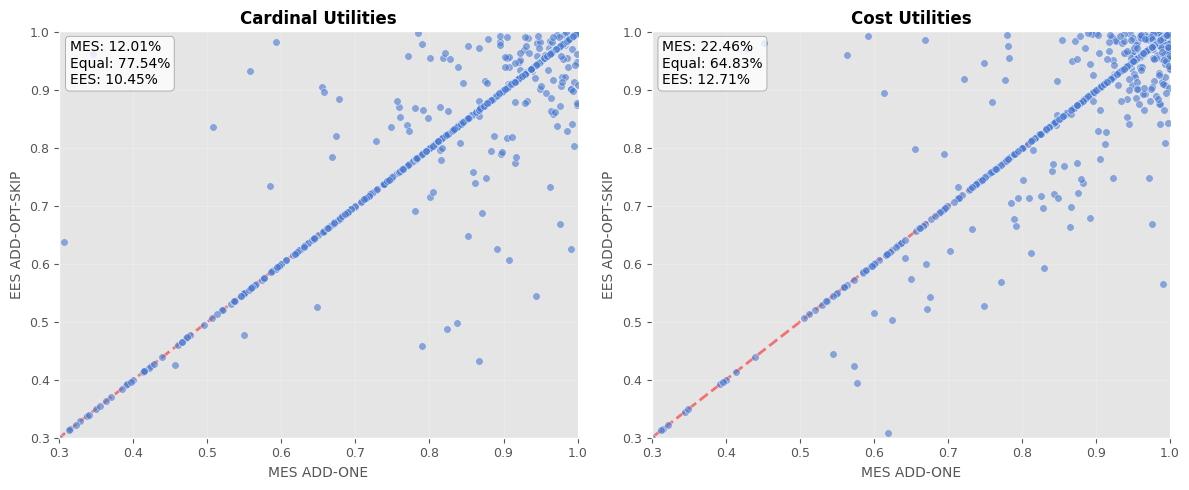

In [122]:
ees_cardinal_add_opt_skip = data['ees_cardinal_add_opt_skip']
mes_cardinal_add_one = data['mes_cardinal_add_one']
ees_cardinal_add_opt_skip, mes_cardinal_add_one = main.intersect_on_election(
    ees_cardinal_add_opt_skip, mes_cardinal_add_one
)

ees_cost_add_opt_skip = data['ees_cost_add_opt_skip']
mes_cost_add_one = data['mes_cost_add_one']
ees_cost_add_opt_skip, mes_cost_add_one = main.intersect_on_election(
    ees_cost_add_opt_skip, mes_cost_add_one
)

plot_functions.comparison_scatter_plot(
    x1=mes_cardinal_add_one['highest_efficiency_attained'],
    y1=ees_cardinal_add_opt_skip['highest_efficiency_attained'],
    x2=mes_cost_add_one['highest_efficiency_attained'],
    y2=ees_cost_add_opt_skip['highest_efficiency_attained'],
    x_label='MES ADD-ONE',
    y_label='EES ADD-OPT-SKIP',
    percentage_labels={'first': 'MES', 'equal': 'Equal', 'second': 'EES'}
)

In [123]:
main.count_thresholds(
    ees_cardinal_add_opt_skip["highest_efficiency_attained"],
    mes_cardinal_add_one["highest_efficiency_attained"],
    label_a="EES Add-Opt-Skip",
    label_b="MES Add-One",
    context="Cardinal"
)

main.count_thresholds(
    ees_cost_add_opt_skip["highest_efficiency_attained"],
    mes_cost_add_one["highest_efficiency_attained"],
    label_a="EES Add-Opt-Skip",
    label_b="MES Add-One",
    context="Cost"
)

Cardinal EES Add-Opt-Skip vs MES Add-One (n=708):
 >1.0 times=74
 1.1 times=29
 1.25 times=10
 1.5 times=5
 2.0 times=2
 max=2.79
 median=1.07
 mean=1.15
Cost EES Add-Opt-Skip vs MES Add-One (n=708):
 >1.0 times=89
 1.1 times=24
 1.25 times=12
 1.5 times=6
 2.0 times=4
 max=11.04
 median=1.04
 mean=1.25


### Compare spending efficiency of EES Add-OPT and EES Add-OPT-SKIP
The purpose of this plot is to see how the skip heuristic compares to the full add-opt. How many budgets does it miss, how does performance suffer?

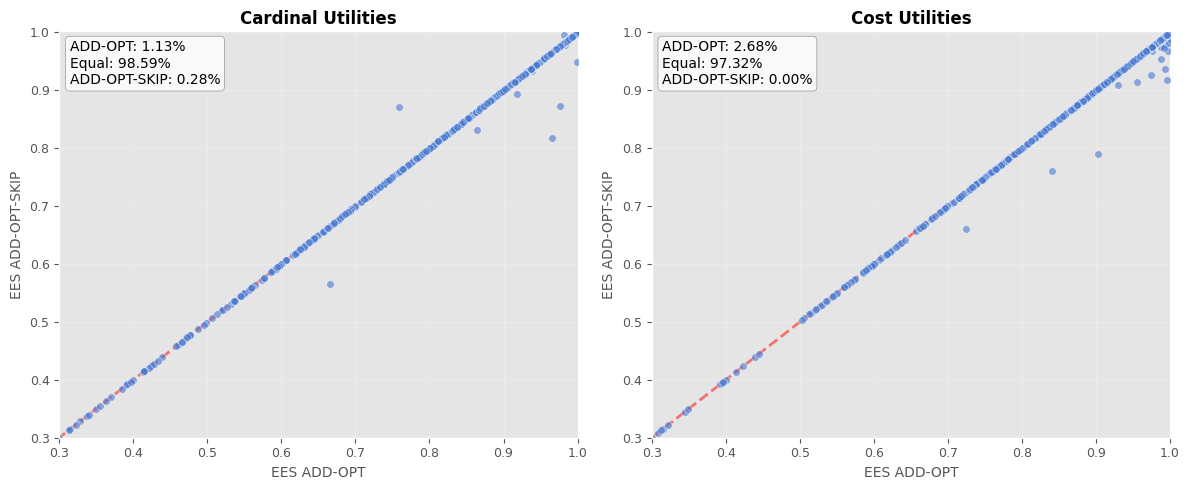

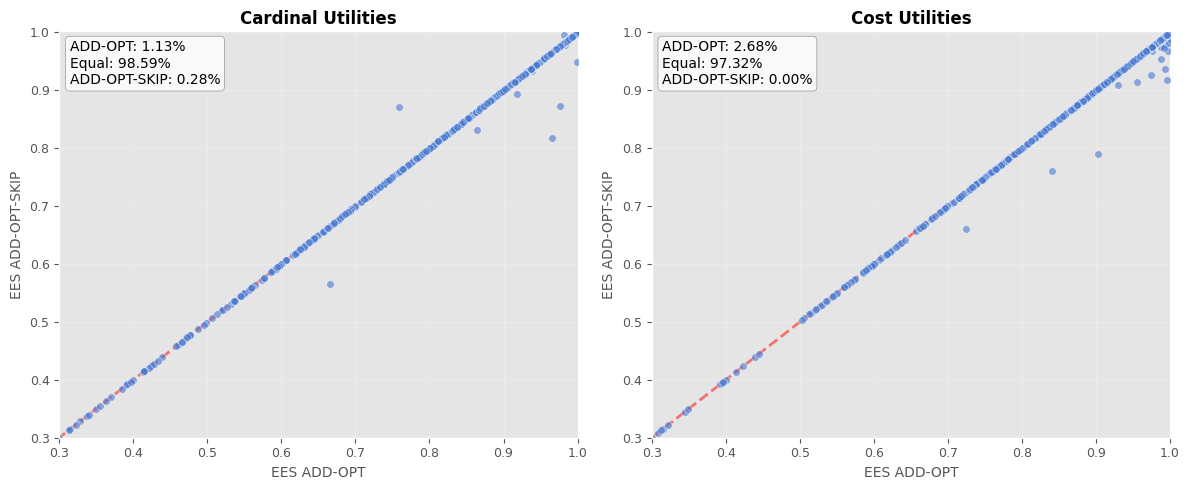

In [124]:
ees_cardinal_add_opt = data['ees_cardinal_add_opt']
ees_cardinal_add_opt_skip = data['ees_cardinal_add_opt_skip']
ees_cardinal_add_opt, ees_cardinal_add_opt_skip = main.intersect_on_election(
    ees_cardinal_add_opt, ees_cardinal_add_opt_skip
)

ees_cost_add_opt = data['ees_cost_add_opt']
ees_cost_add_opt_skip = data['ees_cost_add_opt_skip']
ees_cost_add_opt, ees_cost_add_opt_skip = main.intersect_on_election(
    ees_cost_add_opt, ees_cost_add_opt_skip
)

plot_functions.comparison_scatter_plot(
    x1=ees_cardinal_add_opt['highest_efficiency_attained'],
    y1=ees_cardinal_add_opt_skip['highest_efficiency_attained'],
    x2=ees_cost_add_opt['highest_efficiency_attained'],
    y2=ees_cost_add_opt_skip['highest_efficiency_attained'],
    x_label='EES ADD-OPT',
    y_label='EES ADD-OPT-SKIP',
    percentage_labels={'first': 'ADD-OPT', 'equal': 'Equal', 'second': 'ADD-OPT-SKIP'}
)

In [125]:
main.count_thresholds(
    ees_cardinal_add_opt_skip["highest_efficiency_attained"],
    ees_cardinal_add_opt["highest_efficiency_attained"],
    label_a="EES Add-Opt-Skip",
    label_b="EES Add-Opt",
    context="Cardinal"
)

main.count_thresholds(
    ees_cost_add_opt_skip["highest_efficiency_attained"],
    ees_cost_add_opt["highest_efficiency_attained"],
    label_a="EES Add-Opt-Skip",
    label_b="EES Add-Opt",
    context="Cost"
)

Cardinal EES Add-Opt-Skip vs EES Add-Opt (n=708):
 >1.0 times=2
 1.1 times=1
 1.25 times=0
 1.5 times=0
 2.0 times=0
 max=1.15
 median=1.08
 mean=1.08


ValueError: max() iterable argument is empty

### Compare spending efficiency of MES-none and EES-none
The purpose of this plot is to demonstrate how mes and ees differe as methods when there is no completion. Intuitive expectation would be that mes tends to spend more, and this proves to be true.

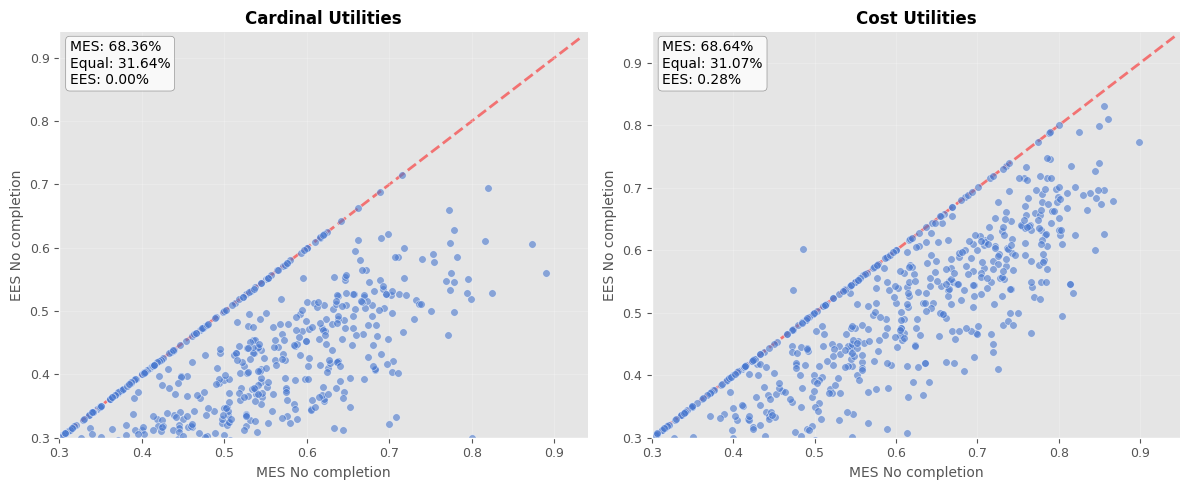

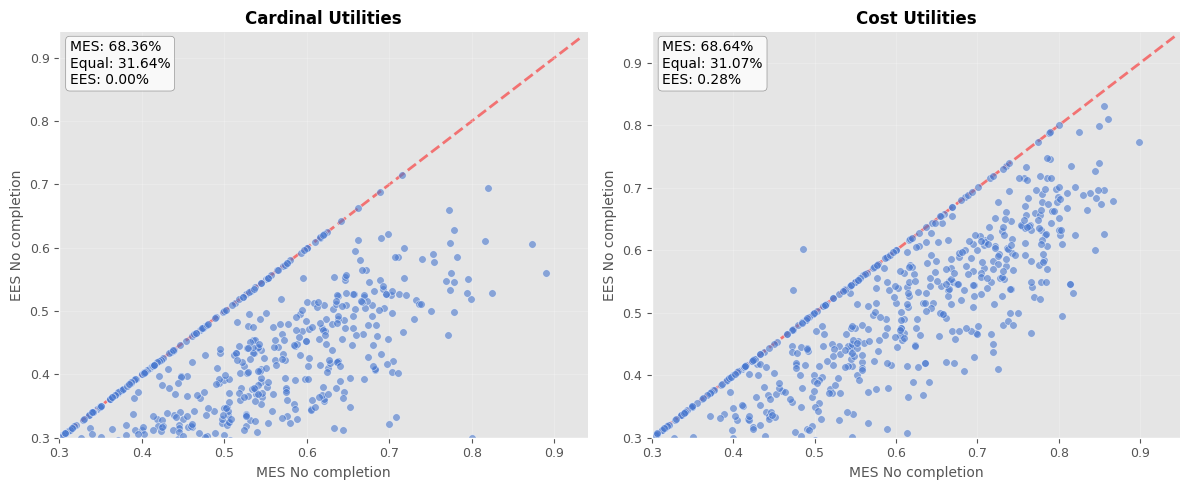

In [126]:
ees_cardinal_none = data['ees_cardinal_none']
mes_cardinal_none = data['mes_cardinal_none']
ees_cardinal_none, mes_cardinal_none = main.intersect_on_election(
    ees_cardinal_none, mes_cardinal_none
)

ees_cost_none = data['ees_cost_none']
mes_cost_none = data['mes_cost_none']
ees_cost_none, mes_cost_none = main.intersect_on_election(
    ees_cost_none, mes_cost_none
)

plot_functions.comparison_scatter_plot(
    x1=mes_cardinal_none['highest_efficiency_attained'],
    y1=ees_cardinal_none['highest_efficiency_attained'],
    x2=mes_cost_none['highest_efficiency_attained'],
    y2=ees_cost_none['highest_efficiency_attained'],
    x_label='MES No completion',
    y_label='EES No completion',
    percentage_labels={'first': 'MES', 'equal': 'Equal', 'second': 'EES'}
)

In [127]:
main.count_thresholds(
    ees_cardinal_none["highest_efficiency_attained"],
    mes_cardinal_none["highest_efficiency_attained"],
    label_a="EES None",
    label_b="MES None",
    context="Cardinal"
)

main.count_thresholds(
    ees_cost_none["highest_efficiency_attained"],
    mes_cost_none["highest_efficiency_attained"],
    label_a="EES None",
    label_b="MES None",
    context="Cost"
)

ValueError: max() iterable argument is empty

### Compare spending efficiency of MES Add-ONE Exhaustive and EES Add-OPT Exhaustive
Here again we compare our new method, using the exhaustive version. This should give the optimal virtual budget for EES, so this is again a comparison of EES to MES as methods. If EES at optimal VB loses to MES Add-ONE exhaustive then it will also lose to MES at its VB.

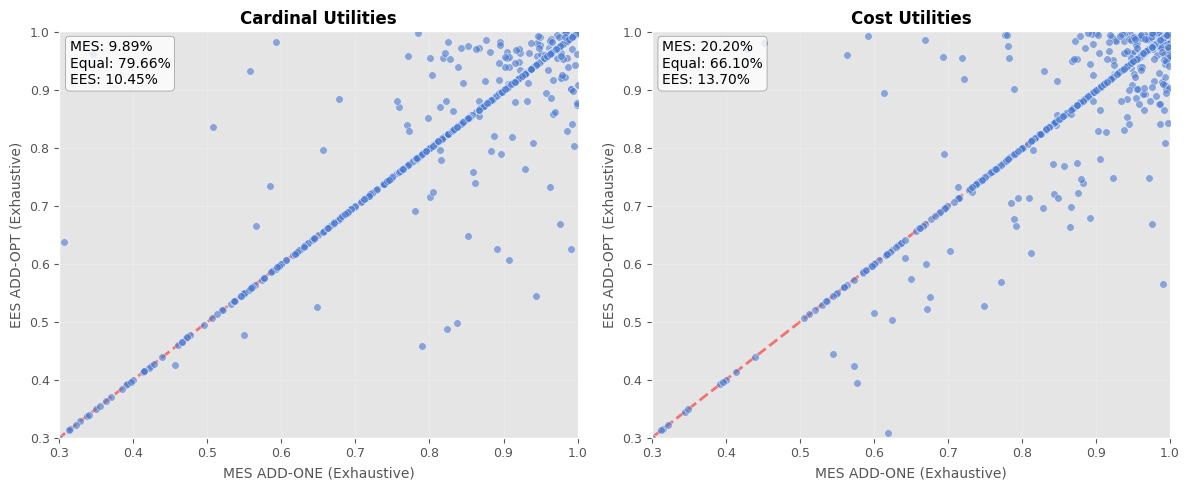

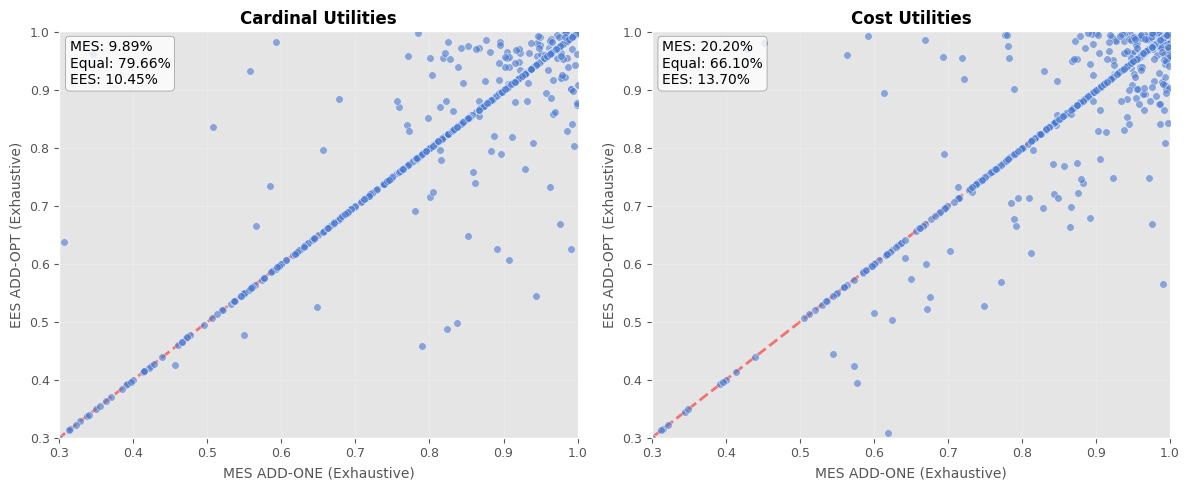

In [128]:
ees_cardinal_add_opt_exhaustive = data['ees_cardinal_add_opt_exhaustive']
mes_cardinal_add_one_exhaustive = data['mes_cardinal_add_one_exhaustive']
ees_cardinal_add_opt_exhaustive, mes_cardinal_add_one_exhaustive = main.intersect_on_election(
    ees_cardinal_add_opt_exhaustive, mes_cardinal_add_one_exhaustive
)

ees_cost_add_opt_exhaustive = data['ees_cost_add_opt_exhaustive']
mes_cost_add_one_exhaustive = data['mes_cost_add_one_exhaustive']
ees_cost_add_opt_exhaustive, mes_cost_add_one_exhaustive = main.intersect_on_election(
    ees_cost_add_opt_exhaustive, mes_cost_add_one_exhaustive
)

plot_functions.comparison_scatter_plot(
    x1=mes_cardinal_add_one_exhaustive['highest_efficiency_attained'],
    y1=ees_cardinal_add_opt_exhaustive['highest_efficiency_attained'],
    x2=mes_cost_add_one_exhaustive['highest_efficiency_attained'],
    y2=ees_cost_add_opt_exhaustive['highest_efficiency_attained'],
    x_label='MES ADD-ONE (Exhaustive)',
    y_label='EES ADD-OPT (Exhaustive)',
    percentage_labels={'first': 'MES', 'equal': 'Equal', 'second': 'EES'}
)

In [129]:
main.count_thresholds(
    ees_cardinal_add_opt_exhaustive["highest_efficiency_attained"],
    mes_cardinal_add_one_exhaustive["highest_efficiency_attained"],
    label_a="EES Add-Opt (Exhaustive)",
    label_b="MES Add-One (Exhaustive)",
    context="Cardinal"
)

main.count_thresholds(
    ees_cost_add_opt_exhaustive["highest_efficiency_attained"],
    mes_cost_add_one_exhaustive["highest_efficiency_attained"],
    label_a="EES Add-Opt (Exhaustive)",
    label_b="MES Add-One (Exhaustive)",
    context="Cost"
)

Cardinal EES Add-Opt (Exhaustive) vs MES Add-One (Exhaustive) (n=708):
 >1.0 times=74
 1.1 times=25
 1.25 times=8
 1.5 times=5
 2.0 times=2
 max=2.79
 median=1.06
 mean=1.14
Cost EES Add-Opt (Exhaustive) vs MES Add-One (Exhaustive) (n=708):
 >1.0 times=95
 1.1 times=24
 1.25 times=14
 1.5 times=6
 2.0 times=4
 max=11.04
 median=1.04
 mean=1.24


## Budget Increases

Need to remake Figure 3

## Full Example

Remake figures 1 and 10

## Dataset Statistics

Remake figure 7

## Non-monotonic instances

Remake figure 4

## Compare ADD-OPT-SKIP number of budget increases to ADD-OPT number of unique efficiencies

## Runtime